# 🧠 Week 8 Exercise: From Counting Words to Attention

In this notebook you'll build three things from scratch:

1. **A bigram language model** — predict text by counting word pairs
2. **Word embedding exploration** — see how meaning lives in vector space
3. **Self-attention** — the mechanism inside transformers and modern LLMs

Look for the `### YOUR CODE HERE ###` markers — that's where you come in.

## ⚙️ Setup — Run this cell first! (takes ~1min takes ~1min to load embedding model)

- defines *corpus* (training set of text) and *vocabulary* (list of valid words)
- defines `softmax` function
- defines word embedding function

In [1]:
# ============================================================
# SETUP — Run this cell once at the start. Nothing to change here.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")
! pip install gensim

# ---------- style ----------
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f9f9f9",
    "axes.grid":        False,
    "font.size":        11,
})
CMAP = "YlOrRd"

# ---------- corpus for Part 1 ----------
raw_corpus = [
    "the cat sat on the mat",
    "the dog sat on the rug",
    "the cat chased the dog",
    "the dog chased the cat",
    "a robot opened the door",
    "the robot closed the door",
    "a cat sat on a mat",
    "the dog opened the door",
    "attention is all you need",
    "the cat is all you need",
    "the robot sat on the mat",
    "a dog chased a cat",
]
corpus = [s.split() for s in raw_corpus]

# build vocabulary (sorted for reproducible ordering)
vocab = sorted(set(w for s in corpus for w in s))
vocab_size = len(vocab)
word_to_idx = {w: i for i, w in enumerate(vocab)}
idx_to_word = {i: w for i, w in enumerate(vocab)}

print(f"✅  Corpus loaded: {len(corpus)} sentences, {vocab_size} unique words")
print(f"    Vocabulary: {vocab}")

# ---------- helper: softmax ----------
def softmax(x, axis=-1):
    """Numerically stable softmax."""
    e = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

# ---------- helper: heatmap ----------
def show_heatmap(matrix, row_labels, col_labels, title="", fmt=".2f",
                 figsize=None, cmap=CMAP, ax=None):
    """Display a labeled heatmap."""
    if ax is None:
        h, w = matrix.shape
        if figsize is None:
            figsize = (max(4, w * 0.55), max(3, h * 0.45))
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure
    im = ax.imshow(matrix, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=9)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix[i, j]
            color = "white" if val > matrix.max() * 0.65 else "black"
            ax.text(j, i, f"{val:{fmt}}", ha="center", va="center",
                    fontsize=8, color=color)
    ax.set_title(title, fontsize=12, pad=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    return fig, ax


# ---------- embeddings for Part 2 ----------
# We'll try to load GloVe 50-d via gensim. If that fails (e.g. offline runtime),
# we fall back to a small built-in embedding set so the notebook still works.
print("\n⏳  Loading word embeddings (this may take a moment the first time)...")

try:
    import gensim.downloader as api
    _glove_model = api.load("glove-wiki-gigaword-50")

    def get_embedding(word):
        return _glove_model[word]

    def find_closest(vector, top_n=5, exclude=None):
        if exclude is None:
            exclude = set()
        sims = {}
        for w in _glove_model.index_to_key[:50_000]:
            if w in exclude:
                continue
            v = _glove_model[w]
            cos = np.dot(vector, v) / (np.linalg.norm(vector) * np.linalg.norm(v) + 1e-10)
            sims[w] = cos
        ranked = sorted(sims.items(), key=lambda x: -x[1])
        return ranked[:top_n]

    EMBEDDINGS_AVAILABLE = True
    print("✅  Word embeddings ready (GloVe 50-d)")

### FALLBACK IF GLOVE DOESN'T LOAD - HARDCODED STUFF ####
except Exception as e:
    print(f"⚠️  Could not load GloVe embeddings: {e}")
    print("    Falling back to a small built-in embedding set so Part 2 still works offline.")
    EMBEDDINGS_AVAILABLE = False

    rng = np.random.default_rng(7)
    _dims = 50
    ## Give dimensions 0-17 each a specific meaning.
    _axes = {
        "royalty": 0,
        "gender": 1,        # male=-1, female=+1
        "human": 2,
        "animal": 3,
        "pet": 4,
        "fruit": 5,
        "vehicle": 6,
        "heavy": 7,
        "country": 8,
        "capital": 9,
        "france": 10,
        "germany": 11,
        "city": 12,
        "positive": 13,
        "negative": 14,
        "intensity": 15,
        "speed": 16,        # slow=-1, fast=+1
        "comparative": 17,
    }

    ## Each word is embedded by hand-coding its values in specific dimensions,
    # e.g. "king" gets values (see in _fallback below):
    # "royalty" axis: 1
    # "gender" axis: -1 (we decide that -1=male, 1=female)
    # "human" axis: 1 (we could also e.g. give animals a value of 0 on this axis and inanimate things -1)
    def _make_vec(**features):
        v = np.zeros(_dims)
        for name, value in features.items():
            v[_axes[name]] = value
        v += rng.normal(scale=0.015, size=_dims)
        return v

    ## Each word is embedded by
    _fallback = {
        "king":     _make_vec(royalty=1.0, gender=-1.0, human=1.0),
        "queen":    _make_vec(royalty=1.0, gender=+1.0, human=1.0),
        "man":      _make_vec(gender=-1.0, human=1.0),
        "woman":    _make_vec(gender=+1.0, human=1.0),
        "cat":      _make_vec(animal=1.0, pet=1.0),
        "dog":      _make_vec(animal=1.0, pet=1.0, heavy=0.05),
        "apple":    _make_vec(fruit=1.0),
        "car":      _make_vec(vehicle=1.0),
        "truck":    _make_vec(vehicle=1.0, heavy=1.0),
        "france":   _make_vec(country=1.0, france=1.0),
        "germany":  _make_vec(country=1.0, germany=1.0),
        "paris":    _make_vec(capital=1.0, city=1.0, france=1.0),
        "berlin":   _make_vec(capital=1.0, city=1.0, germany=1.0),
        "good":     _make_vec(positive=1.0),
        "great":    _make_vec(positive=1.0, intensity=0.8),
        "bad":      _make_vec(negative=1.0),
        "terrible": _make_vec(negative=1.0, intensity=0.9),
        "slow":     _make_vec(speed=-1.0),
        "slower":   _make_vec(speed=-1.0, comparative=1.0),
        "fast":     _make_vec(speed=+1.0),
        "faster":   _make_vec(speed=+1.0, comparative=1.0),
    }

    def get_embedding(word):
        return _fallback[word]

    def find_closest(vector, top_n=5, exclude=None):
        if exclude is None:
            exclude = set()
        results = []
        for w, v in _fallback.items():
            if w in exclude:
                continue
            cos = np.dot(vector, v) / (np.linalg.norm(vector) * np.linalg.norm(v) + 1e-10)
            results.append((w, cos))
        return sorted(results, key=lambda x: -x[1])[:top_n]

print("\n🎉  All set — let's go!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 40.9 MB/s eta 0:00:00
✅  Corpus loaded: 12 sentences, 18 unique words
    Vocabulary: ['a', 'all', 'attention', 'cat', 'chased', 'closed', 'dog', 'door', 'is', 'mat', 'need', 'on', 'opened', 'robot', 'rug', 'sat', 'the', 'you']

⏳  Loading word embeddings (this may take a moment the first time)...
[==================================================] 100.0% 66.0/66.0MB downloaded
✅  Word embeddings ready (GloVe 50-d)

🎉  All set — let's go!


---
# Part 1: Bigram Language Model

A **bigram language model** predicts the next word using only the immediately preceding word. It's an n-gram model with n=2, the simplest one: just count how often word pairs appear, then turn those counts into probabilities, then sample from them.

**The pipeline is:**

(1a) count how often each pair of consecutive words $(\textrm{word}_A, \textrm{word}_B)$ appears in the text. Store this in a *count matrix*: $M_{A, B} = \mathrm{count}(\textrm{"word}_A \textrm{word}_B \textrm{"})$

(1b) turn the counts into *probabilities*: $\mathbb{P}(\textrm{word}_B | \textrm{word}_A) = \frac{\mathrm{count}(\textrm{"word}_A \textrm{word}_B\textrm{"})}{\mathrm{count}(\textrm{word})} = \frac{M_{A,B}}{\textrm{row_sum}(M_{A,B})}$

Now every row of this matrix is a probability distribution over the next word. E.g.: $M_{\textrm{"the"}, \cdot} = \mathbb{P}(\cdot | \textrm{"the"})$ which is a vector of length `vocabulary_size`, and for each word in the vocabulary it contains the probability of appearing after `"the"`.

(1c) to generate text: iteratively sample next words given the current word. If your current sentence is `the cat likes the`, then the count matrix's row for `"the"` is $M_{\textrm{"the"}, \cdot}$ and gives you the probability distribution over all next words. Sample from that distribution to get a next word.

This is what you're asked to implement below.

### Task 1a — Build a bigram count matrix

Below, you're given the corpus as a list of tokenized sentences and a zero-initialized count matrix. To get the vocabulary index of a word, use `word_to_idx(word)`. As described above, we want to end up with a matrix such that $M_{i,j} = \mathrm{count}(\textrm{"idx_to_word(i) idx_to_word(j)"})$.

**Your job:** Fill in the line inside the inner loop that increments the count for each consecutive word pair `(sentence[i], sentence[i+1])`.

In [ ]:
# Task 1a: Build the bigram count matrix
bigram_counts = np.zeros((vocab_size, vocab_size))

for sentence in corpus:
    for i in range(len(sentence) - 1):
        ### YOUR CODE HERE ###  (1 line)
        bigram_counts[word_to_idx[sentence[i]], word_to_idx[sentence[i+1]]] += 1
        #####################


✅  Total bigram count: 53
   count('the' → 'cat') = 4
   count('the' → 'dog') = 4
   count('on' → 'the') = 3
   count('is' → 'all') = 2


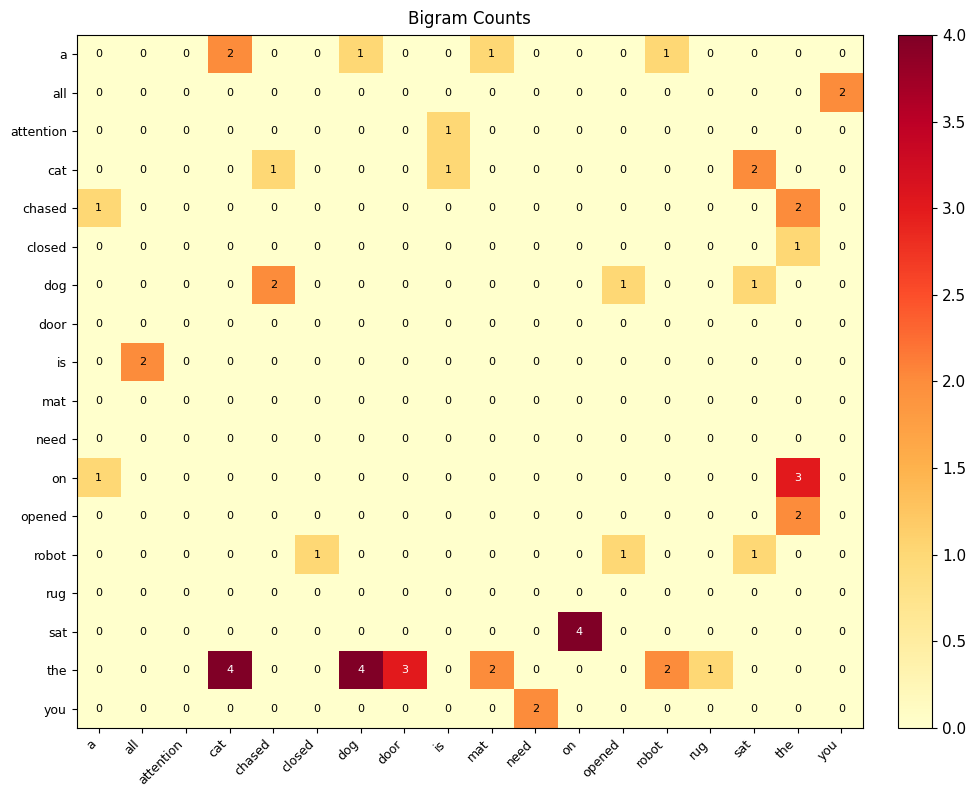

In [ ]:
# ✅ Check 1a — Run this cell to see your count matrix
fig, ax = show_heatmap(bigram_counts, vocab, vocab, title="Bigram Counts", fmt=".0f")
total = bigram_counts.sum()
if total == 0:
    print("❌  The count matrix is all zeros — fill in your code above!")
else:
    print(f"✅  Total bigram count: {int(total)}")
    # Show a few example counts
    for w1, w2 in [("the", "cat"), ("the", "dog"), ("on", "the"), ("is", "all")]:
        c = bigram_counts[word_to_idx[w1], word_to_idx[w2]]
        print(f"   count({w1!r} → {w2!r}) = {int(c)}")
plt.show()


**What just happened?** You scanned every sentence, looked at each consecutive pair of words,
and tallied them up. The heatmap shows which transitions are common — notice how "the" transitions
to many different words, while others are much more specific.

### Task 1b — Convert counts to probabilities

For each word that has at least one observed outgoing transition, its row should become a probability distribution (summing to 1). We want the final matrix to be $\tilde{M}_{A,B} = \mathbb{P}(\textrm{word}_B | \textrm{word}_A) = \frac{\mathrm{count}(\textrm{"word}_A \textrm{word}_B\textrm{"})}{\mathrm{count}(\textrm{word})} = \frac{M_{A,B}}{\textrm{row_sum}(M_{A,B})}$.

**Your job:** Normalize each row by dividing by its row sum `row_sum`.

> **Note:** Because we did **not** add an explicit `<EOS>` token, words that only appear at the end of a sentence can end up with all-zero rows. In this toy example that's okay.


In [ ]:
# Task 1b: Normalize rows to get P(next_word | current_word)
### YOUR CODE HERE ###  (1 line)
row_sums = bigram_counts.sum(axis=1, keepdims=True)  # column vector containing in each row the sum of that row in bigram_counts
#####################

row_sums = np.where(row_sums == 0, 1, row_sums)   # avoid division by zero

### YOUR CODE HERE ###  (1 line)
bigram_probs = bigram_counts / row_sums  # hint: element-wise division
#####################


✅  All non-zero rows sum to 1!
   P(? | "the") = { cat: 0.25, dog: 0.25, door: 0.19, mat: 0.12, robot: 0.12, rug: 0.06 }
   P(? | "on") = { the: 0.75, a: 0.25 }
   P(? | "a") = { cat: 0.40, dog: 0.20, mat: 0.20, robot: 0.20 }


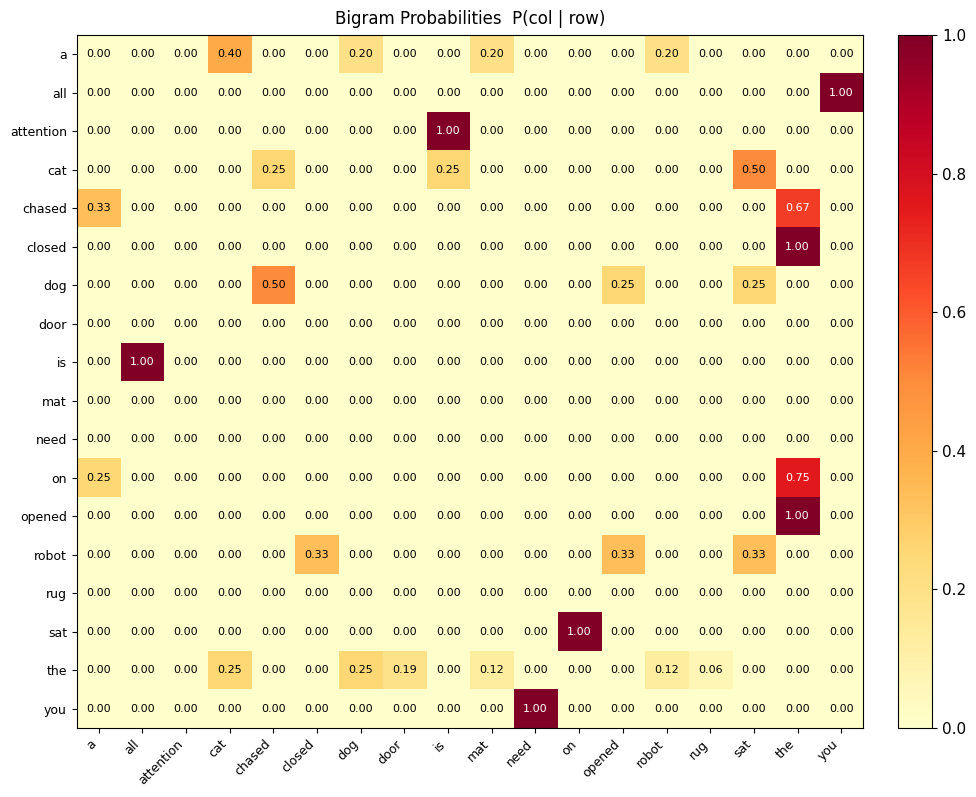

In [ ]:
# ✅ Check 1b — Run this to see the probability matrix
if bigram_probs is None or not isinstance(bigram_probs, np.ndarray):
    print("❌  bigram_probs isn't set yet — fill in the code above!")
else:
    fig, ax = show_heatmap(bigram_probs, vocab, vocab,
                           title="Bigram Probabilities  P(col | row)", fmt=".2f")
    # Verify rows sum to 1
    sums = bigram_probs.sum(axis=1)
    ok = np.allclose(sums[sums > 0], 1.0)
    print("✅  All non-zero rows sum to 1!" if ok else "❌  Some non-zero rows don't sum to 1 — check your code.")
    # Show human-readable examples
    for w in ["the", "on", "a"]:
        row = bigram_probs[word_to_idx[w]]
        nonzero = [(idx_to_word[j], row[j]) for j in range(vocab_size) if row[j] > 0]
        parts = ", ".join(f"{w2}: {p:.2f}" for w2, p in sorted(nonzero, key=lambda x: -x[1]))
        print(f'   P(? | "{w}") = {{ {parts} }}')
    plt.show()


**What just happened?** You turned raw counts into conditional probabilities. Each non-terminal row now
answers the question: *"If the current word is X, what's the distribution over the next word?"*
This is your language model!

> Small technical note: some words only appear at the end of a sentence in this toy corpus, so their rows stay all zeros because we didn't include an explicit end-of-sentence token.


### Task 1c — Generate text by sampling

Now let's use the model to generate text! Starting from a given word, repeatedly sample the
next word from the probability distribution in that word's row.

**Your job:** Fill in the lines that sample the next word and append it to the already generated text.

*Hint:* `np.random.choice(n, p=probs)` returns an index sampled from distribution `probs`.

In [ ]:
from logging import currentframe
# Task 1c: Generate text from the bigram model
def generate_bigram(start_word, length=10):
    """Generate a sequence of words starting from start_word."""
    current = start_word
    result = [current]
    for _ in range(length - 1):
        probs = bigram_probs[word_to_idx[current]]
        if probs.sum() == 0:
            break
        ### YOUR CODE HERE ###  (3 lines)
        next_idx = np.random.choice(vocab_size, p=probs)  # sample next word (or rather its vocabulary index) from "probs" = P( . | current word)
        current = idx_to_word[next_idx]  # convert vocab index into word
        result.append(current)  # append word to result
        #####################
    return " ".join(result)


In [ ]:
# ✅ Check 1c — Generate some text!
np.random.seed(None)  # fresh randomness each time
print("🎲 Generated text from your bigram model:\n")
for i, start in enumerate(["the", "a", "attention"], 1):
    for j in range(3):
        print(f"  {start:>12s} →  {generate_bigram(start, length=10)}")
    print()


🎲 Generated text from your bigram model:

           the →  the rug
           the →  the dog chased the door
           the →  the robot opened the mat

             a →  a cat chased the cat sat on the mat
             a →  a mat
             a →  a cat sat on the cat sat on a cat

     attention →  attention is all you need
     attention →  attention is all you need
     attention →  attention is all you need



**What just happened?** Your bigram model generates text that often makes **local** sense
(consecutive word pairs look fine) but quickly becomes incoherent. That's the fundamental
limitation: the model only remembers one word of context.

> 🔗 **Modern connection:** ChatGPT is also "just" a language model — it predicts the next token
> given all preceding tokens. The difference is that transformers can attend to *thousands* of
> tokens of context, not just one. Same principle, vastly more context.

---
# Part 2: Word Embeddings & Similarity

So far, words are just discrete symbols — indices into a vocabulary. There's no notion that
"cat" and "dog" are more similar than "cat" and "door".

**Word embeddings** fix this by mapping each word to a dense vector where proximity ≈ similarity.
We'll explore pre-trained [GloVe](https://nlp.stanford.edu/projects/glove/) embeddings (50 dimensions).

### Task 2a — Cosine similarity by hand

Cosine similarity measures how similar two vectors' **directions** are, ignoring magnitude:

$$\text{cosine_similarity}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \; \|\mathbf{b}\|}$$

**Your job:** Implement this formula with numpy's `np.dot`, `np.linalg.norm`.

In [2]:
# Task 2a: Implement cosine similarity
def cosine_similarity(a, b):
    ### YOUR CODE HERE ###  (1 line)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10)
    #####################


In [3]:
# ✅ Check 2a — Compare some word pairs
pairs = [
    ("king", "queen"),
    ("cat", "dog"),
    ("king", "apple"),
]
print("📐 Cosine similarities:\n")
for w1, w2 in pairs:
    v1, v2 = get_embedding(w1), get_embedding(w2)
    sim = cosine_similarity(v1, v2)
    bar = "█" * int(max(0, sim) * 30)
    print(f"   {w1:>8s}  ↔  {w2:<8s}  :  {sim:+.4f}  {bar}")

# Quick sanity check
v = get_embedding("king")
self_sim = cosine_similarity(v, v)
print(f"\n   Self-similarity check: cosine(king, king) = {self_sim:.4f}",
      "✅" if abs(self_sim - 1.0) < 1e-5 else "❌ (should be 1.0)")


📐 Cosine similarities:

       king  ↔  queen     :  +0.7839  ███████████████████████
        cat  ↔  dog       :  +0.9218  ███████████████████████████
       king  ↔  apple     :  +0.3047  █████████

   Self-similarity check: cosine(king, king) = 1.0000 ✅


**What just happened?** Semantically related words (king ↔ queen, cat ↔ dog) have high
cosine similarity, while unrelated words (king ↔ apple) have low similarity. The embeddings
"know" about meaning — even though they were trained only on word co-occurrence statistics!

### Task 2b — The classic embedding analogy

A famous result from static word embeddings is: **king − man + woman ≈ queen**.

The idea is that vector arithmetic can capture semantic relationships: the "gender direction"
(man → woman) applied to "king" lands near "queen".

**Your job:** Compute the analogy vector

In [4]:
# Task 2b: Word analogy — king - man + woman = ?
vec_king  = get_embedding("king")
vec_man   = get_embedding("man")
vec_woman = get_embedding("woman")

### YOUR CODE HERE ###  (1 line)
analogy_vector = vec_king - vec_man + vec_woman
#####################


In [5]:
# ✅ Check 2b — What's closest to king - man + woman?
if analogy_vector is None or not isinstance(analogy_vector, np.ndarray):
    print("❌  analogy_vector isn't set yet!")
else:
    closest = find_closest(analogy_vector, top_n=5, exclude={"king", "man", "woman"})
    print("👑 king − man + woman  ≈ ...\n")
    for rank, (word, sim) in enumerate(closest, 1):
        marker = " ← 🎯" if word == "queen" else ""
        print(f"   {rank}. {word:<12s}  (similarity: {sim:.4f}){marker}")


👑 king − man + woman  ≈ ...

   1. queen         (similarity: 0.8610) ← 🎯
   2. daughter      (similarity: 0.7685)
   3. prince        (similarity: 0.7641)
   4. throne        (similarity: 0.7635)
   5. princess      (similarity: 0.7513)


**What just happened?** The embedding space learned that the direction from "man" to "woman"
is roughly the same as from "king" to "queen". This is a *geometric* encoding of a *semantic*
relationship — one of the coolest results in NLP.

**Try more analogies!** Modify the cell below and re-run. Some ideas:
- `paris - france + germany` → berlin?
- `slow - slower + fast` → faster?

In [9]:
# 🧪 Playground — Try your own analogies!
# Change the three words and re-run.
word_a, word_b, word_c = "car", "engine", "wings"
# Analogy: a - b + c = ?

try:
    vec = get_embedding(word_a) - get_embedding(word_b) + get_embedding(word_c)
    closest = find_closest(vec, top_n=5, exclude={word_a, word_b, word_c})
    print(f"🔍 {word_a} − {word_b} + {word_c}  ≈ ...\n")
    for rank, (word, sim) in enumerate(closest, 1):
        print(f"   {rank}. {word:<12s}  (similarity: {sim:.4f})")
except KeyError as e:
    print(f"⚠️  Word not found in embeddings: {e}")


🔍 car − engine + wings  ≈ ...

   1. wearing       (similarity: 0.7086)
   2. red           (similarity: 0.6849)
   3. wore          (similarity: 0.6761)
   4. pulled        (similarity: 0.6706)
   5. jackets       (similarity: 0.6546)


### Task 2c — Visualize embedding space (exploration, no code to fill in)

Let's project high-dimensional word vectors down to 2D using PCA and see if semantic clusters
emerge. Just run the cell and explore — try changing the word list!

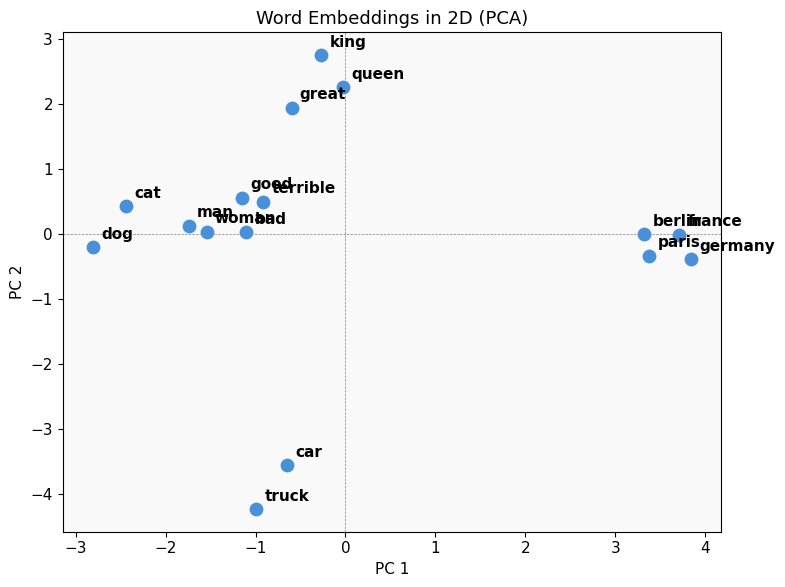

In [10]:
# 🗺️ Explore — Modify the word list and re-run!
words_to_plot = [
    "king", "queen", "man", "woman",
    "cat", "dog",
    "car", "truck",
]

# If full embeddings available, add more interesting words
if EMBEDDINGS_AVAILABLE:
    words_to_plot += ["paris", "france", "berlin", "germany",
                      "good", "great", "bad", "terrible"]

# Gather vectors
vecs, labels = [], []
for w in words_to_plot:
    try:
        vecs.append(get_embedding(w))
        labels.append(w)
    except KeyError:
        pass

vecs = np.array(vecs)

# PCA to 2D
from numpy.linalg import svd
vecs_centered = vecs - vecs.mean(axis=0)
U, S, Vt = svd(vecs_centered, full_matrices=False)
coords = vecs_centered @ Vt[:2].T

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(coords[:, 0], coords[:, 1], s=80, c="#4A90D9", zorder=3)
for i, w in enumerate(labels):
    ax.annotate(w, (coords[i, 0], coords[i, 1]),
                fontsize=11, fontweight="bold",
                textcoords="offset points", xytext=(6, 6))
ax.set_title("Word Embeddings in 2D (PCA)", fontsize=13)
ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.axvline(0, color="gray", lw=0.5, ls="--")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
fig.tight_layout()
plt.show()


**What just happened?** Even in a crude 2D projection you can see that semantically similar
words cluster together: (king, queen) near (man, woman), (cat, dog) in their own area, etc.

> 🔗 **Modern connection:** Today's LLMs don't use static embeddings like word2vec. Instead,
> each transformer layer produces **contextual** embeddings — the vector for "bank" is different
> in "river bank" vs "bank account". But the core idea of encoding meaning as geometry in
> vector space started right here.

---
# Part 3: Self-Attention from Scratch

This is the big one. **Self-attention** is the core mechanism inside every transformer — and
therefore inside every modern LLM. You're going to implement it step by step on a tiny example
so you can see exactly what happens.

We'll work with a 3-word sentence: **"the cat sat"**, embedded as 3 vectors of dimension 4.
Small enough to read every number, big enough to see the pattern.

In [11]:
# Setup for Part 3 — Nothing to change, just run.
np.random.seed(42)

sentence = ["the", "cat", "sat"]
n_tokens = len(sentence)
d_model = 4   # embedding dimension

# Tiny random embeddings for our 3 tokens
X = np.round(np.random.randn(n_tokens, d_model) * 0.5, 2)

# Learned weight matrices for Q, K, V
W_Q = np.round(np.random.randn(d_model, d_model) * 0.5, 2)
W_K = np.round(np.random.randn(d_model, d_model) * 0.5, 2)
W_V = np.round(np.random.randn(d_model, d_model) * 0.5, 2)

d_k = d_model  # key dimension (used for scaling)

print("📝 Sentence:", sentence)
print(f"\n📊 Embedding matrix X  (shape {X.shape}):")
for i, w in enumerate(sentence):
    print(f"   {w:>4s} → {X[i]}")
print(f"\n🔧 Weight matrices W_Q, W_K, W_V  (each {W_Q.shape})  — these are the learnable parameters")


📝 Sentence: ['the', 'cat', 'sat']

📊 Embedding matrix X  (shape (3, 4)):
    the → [ 0.25 -0.07  0.32  0.76]
    cat → [-0.12 -0.12  0.79  0.38]
    sat → [-0.23  0.27 -0.23 -0.23]

🔧 Weight matrices W_Q, W_K, W_V  (each (4, 4))  — these are the learnable parameters


### Task 3a — Compute Q, K, V

The first step of self-attention is to project each token embedding into three roles:
- **Q** (Query): "What am I looking for?"
- **K** (Key): "What do I contain?"
- **V** (Value): "What information do I provide if attended to?"

Each is a simple matrix multiplication: `Q = X @ W_Q`, etc.

**Your job:** Compute all three.

In [12]:
# Task 3a: Compute Q, K, V from X using the weight matrices
### YOUR CODE HERE ###  (3 short lines)
Q = X @ W_Q
K = X @ W_K
V = X @ W_V
#####################


In [13]:
# ✅ Check 3a
def _check_qkv():
    if Q is ... or K is ... or V is ...:
        print("❌  Q, K, V aren't set yet!")
        return False
    ok = True
    for name, mat, W in [("Q", Q, W_Q), ("K", K, W_K), ("V", V, W_V)]:
        expected = X @ W
        if not np.allclose(mat, expected):
            print(f"❌  {name} doesn't match X @ W_{name}. Check your code!")
            ok = False
        else:
            print(f"✅  {name}  (shape {mat.shape}):")
            for i, w in enumerate(sentence):
                print(f"      {w:>4s} → {np.round(mat[i], 3)}")
    return ok
_check_qkv()
print("""
💡 Each row of Q is that token's query ("what am I looking for?").
   Each row of K is that token's key ("what do I contain?").
   Each row of V is that token's value ("what info do I provide?").""")


✅  Q  (shape (3, 4)):
       the → [ 0.094 -0.241 -0.615 -0.103]
       cat → [ 0.521  0.032 -0.039 -0.37 ]
       sat → [-0.271  0.276  0.203 -0.008]
✅  K  (shape (3, 4)):
       the → [ 0.239 -0.246 -0.36   0.193]
       cat → [ 0.257 -0.658 -0.557 -0.016]
       sat → [-0.042  0.096  0.345 -0.367]
✅  V  (shape (3, 4)):
       the → [-0.625 -0.043  0.227  0.669]
       cat → [-0.36   0.337  0.484  0.517]
       sat → [ 0.391 -0.192 -0.063 -0.394]

💡 Each row of Q is that token's query ("what am I looking for?").
   Each row of K is that token's key ("what do I contain?").
   Each row of V is that token's value ("what info do I provide?").


### Task 3b — Compute attention scores

Next, we compute how much each token wants to attend to every other token.
This is done by taking the dot product of queries with keys (then scaling):

$$\text{scores} = \frac{Q \cdot K^T}{\sqrt{d_k}}$$

The scaling by √d_k prevents the dot products from getting too large (which would
make the subsequent softmax saturate).

**Your job:** Compute the scaled score matrix.

In [14]:
# Task 3b: Compute scaled attention scores
### YOUR CODE HERE ###  (1 line)
scores = (Q @ K.T) / np.sqrt(d_k)
#####################


✅  Attention scores  (shape (3, 3)):


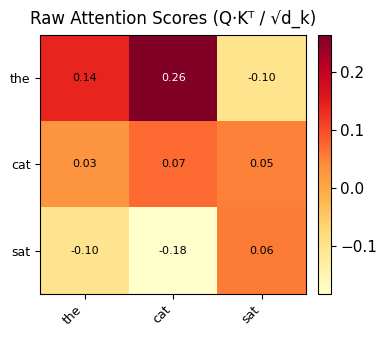

💡 Entry (i,j) tells us how much token i "wants to look at" token j.


In [15]:
# ✅ Check 3b
if scores is ... or not isinstance(scores, np.ndarray):
    print("❌  scores isn't set yet!")
else:
    expected = (Q @ K.T) / np.sqrt(d_k)
    if np.allclose(scores, expected):
        print(f"✅  Attention scores  (shape {scores.shape}):")
        fig, ax = show_heatmap(scores, sentence, sentence,
                               title="Raw Attention Scores (Q·Kᵀ / √d_k)",
                               figsize=(4, 3.5))
        plt.show()
        print('💡 Entry (i,j) tells us how much token i "wants to look at" token j.')
    else:
        print("❌  Scores don't match expected — check your formula!")


### Task 3c — Softmax → attention weights

The raw scores are just numbers — we need proper probabilities. Apply **softmax** row-wise
so each row becomes a distribution that sums to 1.

**Your job:** Apply softmax to the scores (row-wise). (CTRL+F `softmax` for the definition)

In [17]:
# Task 3c: Apply softmax to get attention weights
### YOUR CODE HERE ###  (1 line)
attention_weights = softmax(scores, axis=1)
#####################


✅  Rows sum to 1!


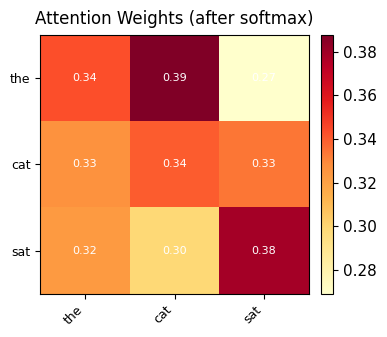

💡 Each row is now a probability distribution —
   it tells us how much each token "pays attention" to every other token.


In [18]:
# ✅ Check 3c
if attention_weights is ... or not isinstance(attention_weights, np.ndarray):
    print("❌  attention_weights isn't set yet!")
else:
    row_sums = attention_weights.sum(axis=1)
    ok = np.allclose(row_sums, 1.0)
    print("✅  Rows sum to 1!" if ok else "❌  Rows don't sum to 1 — check axis parameter.")
    if ok:
        fig, ax = show_heatmap(attention_weights, sentence, sentence,
                               title="Attention Weights (after softmax)",
                               figsize=(4, 3.5))
        plt.show()
        print("💡 Each row is now a probability distribution —")
        print('   it tells us how much each token "pays attention" to every other token.')


### Task 3d — Compute the final output

The final step: use the attention weights to take a **weighted average** of the value vectors.

$$\text{output} = \text{attention_weights} \times V$$

Each output row is a blend of all value vectors, mixed according to how much that token attended to each position.

**Your job:** calc the output

In [20]:
# Task 3d: Weighted sum of values
### YOUR CODE HERE ###  (1 line)
output = attention_weights @ V
#####################


In [21]:
# ✅ Check 3d
if output is ... or not isinstance(output, np.ndarray):
    print("❌  output isn't set yet!")
else:
    expected = attention_weights @ V
    if np.allclose(output, expected):
        print(f"✅  Self-attention output  (shape {output.shape}):")
        for i, w in enumerate(sentence):
            print(f"   {w:>4s} → {np.round(output[i], 3)}")
        print("""
💡 Each row is now a context-aware representation of that token.
   Unlike the original embeddings, these vectors "know about" the other tokens
   in the sentence — the attention mechanism mixed information between positions.""")
    else:
        print("❌  Output doesn't match expected — check your formula!")


✅  Self-attention output  (shape (3, 4)):
    the → [-0.249  0.064  0.249  0.324]
    cat → [-0.196  0.036  0.218  0.262]
    sat → [-0.161  0.014  0.194  0.221]

💡 Each row is now a context-aware representation of that token.
   Unlike the original embeddings, these vectors "know about" the other tokens
   in the sentence — the attention mechanism mixed information between positions.


### 🎬 The full self-attention pipeline

Run the cell below to see the entire pipeline in one view — from input embeddings through
Q/K/V, scores, attention weights, to the final contextualized output.

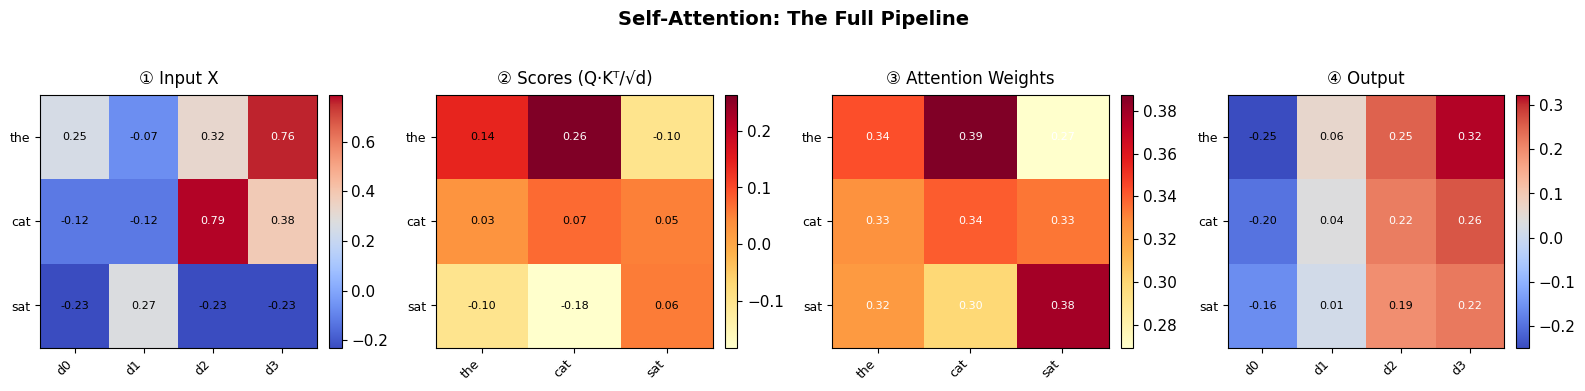


📌 Summary of what you just built:
   ① Start with token embeddings X
   ② Compute Q, K, V projections → score every pair of tokens
   ③ Softmax the scores → each token gets an attention distribution
   ④ Weighted-average the values → output is a context-enriched representation

   This is ONE self-attention head. A real transformer stacks dozens of these
   (with multiple heads per layer) to build rich, contextualized representations.



In [22]:
# 🎬 Full pipeline visualization — just run this cell
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))

show_heatmap(X, sentence, [f"d{j}" for j in range(d_model)],
             title="① Input X", ax=axes[0], cmap="coolwarm")

show_heatmap(scores, sentence, sentence,
             title="② Scores (Q·Kᵀ/√d)", ax=axes[1])

show_heatmap(attention_weights, sentence, sentence,
             title="③ Attention Weights", ax=axes[2])

show_heatmap(output, sentence, [f"d{j}" for j in range(d_model)],
             title="④ Output", ax=axes[3], cmap="coolwarm")

fig.suptitle("Self-Attention: The Full Pipeline", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

print("""
📌 Summary of what you just built:
   ① Start with token embeddings X
   ② Compute Q, K, V projections → score every pair of tokens
   ③ Softmax the scores → each token gets an attention distribution
   ④ Weighted-average the values → output is a context-enriched representation

   This is ONE self-attention head. A real transformer stacks dozens of these
   (with multiple heads per layer) to build rich, contextualized representations.
""")


### 🎁 Bonus — Causal masking (if time permits)

In a **decoder** (like GPT), tokens must not look into the future — you can't predict
the next word by peeking at it! This is enforced by setting the upper-triangle scores to
−∞ before softmax, so those positions get zero attention weight.

Just run the cell below to see how the attention pattern changes.

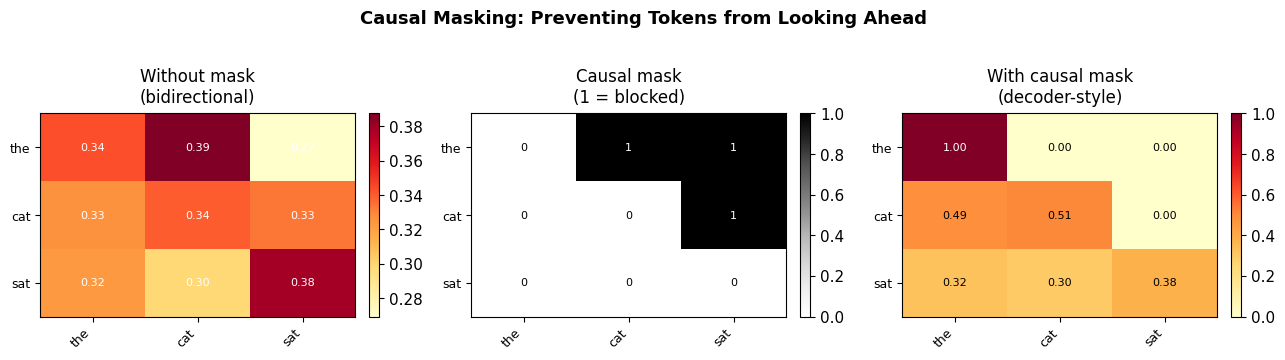

💡 With the causal mask:
   • "the" can only attend to itself (it's the first token)
   • "cat" can attend to "the" and itself
   • "sat" can attend to all three (nothing is ahead of it)

   This is exactly what GPT-style language models do — they generate text
   left-to-right, never looking ahead.



In [23]:
# 🎁 Bonus: Causal (autoregressive) masking
mask = np.triu(np.ones((n_tokens, n_tokens)), k=1)  # upper triangle = 1
masked_scores = scores.copy()
masked_scores[mask == 1] = -1e9  # set future positions to -infinity

masked_weights = softmax(masked_scores, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

show_heatmap(attention_weights, sentence, sentence,
             title="Without mask\n(bidirectional)", ax=axes[0])

show_heatmap(mask, sentence, sentence,
             title="Causal mask\n(1 = blocked)", ax=axes[1], fmt=".0f", cmap="Greys")

show_heatmap(masked_weights, sentence, sentence,
             title="With causal mask\n(decoder-style)", ax=axes[2])

fig.suptitle("Causal Masking: Preventing Tokens from Looking Ahead",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

print("""💡 With the causal mask:
   • "the" can only attend to itself (it's the first token)
   • "cat" can attend to "the" and itself
   • "sat" can attend to all three (nothing is ahead of it)

   This is exactly what GPT-style language models do — they generate text
   left-to-right, never looking ahead.
""")


---
# 🏁 Wrap-up

You just built three foundational NLP components from scratch:

| What you built | Key idea | Limitation |
|---|---|---|
| **Bigram model** | Predict next word from counts | Only 1 word of context |
| **Word embeddings** | Meaning as geometry in vector space | Static — same vector regardless of context |
| **Self-attention** | Let every token dynamically attend to every other | Quadratic cost in sequence length |

Each one was a stepping stone toward the next, and together they tell the story of how we got
from counting word pairs to transformers and large language models.

> 🔗 **The modern stack in one sentence:** Take self-attention, add positional encodings,
> stack it many times with residual connections and layer norm, train it on massive text corpora
> to predict the next token → you get GPT.
